**KNN**

According to this algorithm, which is used in classification, feature extraction during classification is used to look at the closeness of the new individual to be categorized to k of the previous individuals.
For example, you want to classify a new element for k = 3. in this case the nearest 3 of the old classified elements are taken. If these elements are included in the class, the new element is also included in that class. The euclide distance can be used in the distance calculation.

In [450]:
# Site visited :  https://archive.ics.uci.edu/ml/datasets/Vertebral%20Column 
# Each patient is represented in the data set by six biomechanical attributes derived from the shape and orientation of
# the pelvis and lumbar spine
#
# 2Classdata.csv
#
# Total 310 datapoints
# Features are pelvic_incidence,pelvic_tilt_numeric,lumbar_lordosis_angle, sacral_slope, pelvic_radius, degree_spondylolisthesis
# and class
# class is target variable [Two values - Abnormal[200 data points] and Normal[100]]
#lumbar lordosis angle is positively and significantly associated with spondylolysis and isthmic spondylolisthesis. 

# Project - Classify Type of Patient from the biomechanical features of orthopedic patients. (Total 30 marks)

# Install the necessary libraries (1 mark)


In [451]:
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import pyplot
%matplotlib inline
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix 
from sklearn.model_selection import cross_val_score

# import data 2C_weka.csv for 2 Class Classifcation. (1 mark)


In [452]:
# Read the data file
twoClassdata_df = pd.read_csv("2Classdata.csv")

# Explore the data set.Get necessary information about the data. (4 marks)

Look at the head and tail of dataset.
Find the missing value.
Look at the unique values of class values.
Look at the distribution of class values and other attributes.
Get the datatype information about the dataset
Plot the distribution of different classes for pelvic_radius and sacral_slope for visualization.

In [453]:
twoClassdata_df.info()
#All values are float and class target variable is categorical. No missing values
# Total 7 columns and 310 observations
# Data size seems to be apt for KNN (computationally OK)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 7 columns):
pelvic_incidence            310 non-null float64
pelvic_tilt numeric         310 non-null float64
lumbar_lordosis_angle       310 non-null float64
sacral_slope                310 non-null float64
pelvic_radius               310 non-null float64
degree_spondylolisthesis    310 non-null float64
class                       310 non-null object
dtypes: float64(6), object(1)
memory usage: 17.0+ KB


In [454]:
twoClassdata_df.dtypes.value_counts()
#6 float and 1 obejct

float64    6
object     1
dtype: int64

In [455]:
twoClassdata_df.describe().T
# Mean of features vary between 17 to 117 so not much disparity in scale of the features [Still normalization is the best and safe 
# way forward]
# Max value more than 1.5 IQR() + Q3 indicates presence of positive outliers and Min value less than Q1-1.5IQR indicates
# presence of negative outliers
#
# pelvic_incidence has mean slightly more than median which indicates slight right skew [IQR =26.447, upper bound = 112.54879795,
# lower bound=6.75919205000001, 
#  Max value greater than upper bound indicating outliers towards upper side
#
# pelvic_tilt numeric mean slightly more than median so slight right skew [IQR= 11.453326, Max Bound=39.30038352,
# MinBounds = -6.512919520000002 ]
# Max value more than MaxBound indicating positive outliers. Minimum value slightly less than min bound indicating one 
# negative outlier
# lumbar_lordosis_angle mean slightly more than median so slight rigt skew[IQR = 25.99999, MaxLimit=101.9999999,
# MinLimit =-1.99999]
# Max greater than MaxLimit so positive outliers exist
# 
# sacral_slope mean is almost equal to median so distribution is normal[IQR= 19.3487663425, MaxLimit=81.7190375
# MinLimit=4.32397248]
# Max value is higher than MaxLimit indicates positive outliers 
#
# pelvic_radius mean almost equal to median so normal distribution [IQR=14.758478, MaxLimit = 147.605391  MinLimit=88.5714788]
# Max value is higher than MaxLimit indicates positive outliers , Minvalue less than MinLimit indicates negative outliers 
# as well
#
# degree_spondylolisthesis mean > median long right skew [IQR=39.683625, MaxLimit=100.8127 , MinLimit=-57.9217]. 
# Also max value is very high as per Maxlimit so very big positive outlier 
# (KNN not greatly impacted by outliers though. Is it why we are going for KNN in this case)

,count,mean,std,min,25%,50%,75%,max
pelvic_incidence,310.0,60.496653,17.236520,26.147921,46.430294,58.691038,72.877696,129.834041
pelvic_tilt numeric,310.0,17.542822,10.008330,-6.554948,10.667069,16.357689,22.120395,49.431864
lumbar_lordosis_angle,310.0,51.930930,18.554064,14.000000,37.000000,49.562398,63.000000,125.742385
sacral_slope,310.0,42.953831,13.423102,13.366931,33.347122,42.404912,52.695888,121.429566
pelvic_radius,310.0,117.920655,13.317377,70.082575,110.709196,118.268178,125.467674,163.071041
degree_spondylolisthesis,310.0,26.296694,37.559027,-11.058179,1.603727,11.767934,41.287352,418.543082


In [456]:
# Drawing Boxplots to visualize our inferences from describe above

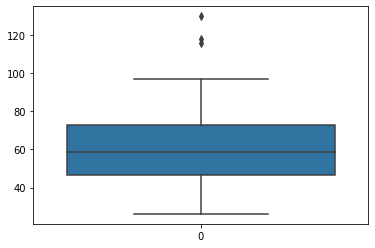

In [457]:
# Let us draw boxplots for better visualization of spread and 5 point summry
sns.boxplot(data=twoClassdata_df['pelvic_incidence'])
#has positive outliers and has median at 59 and has positive outliers

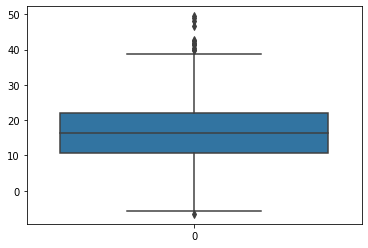

In [458]:
sns.boxplot(data=twoClassdata_df['pelvic_tilt numeric'])
# pelvic_tilt median is at 16 and almost normal distribution with one negative outliers and many positive outliers 

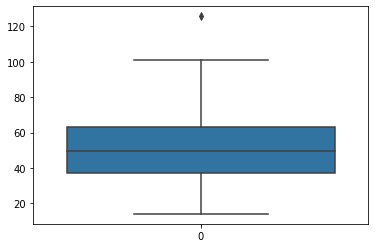

In [459]:
sns.boxplot(data=twoClassdata_df['lumbar_lordosis_angle'])
#little right skew and one positive outlier

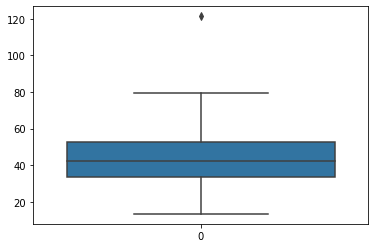

In [460]:
sns.boxplot(data=twoClassdata_df['sacral_slope'])
#Normal distribution with one positive outlier which would be max value

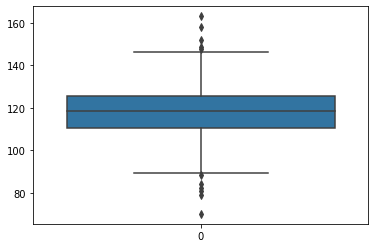

In [461]:
sns.boxplot(data=twoClassdata_df['pelvic_radius'])
#Normal distribution with positive as well as negative outliers

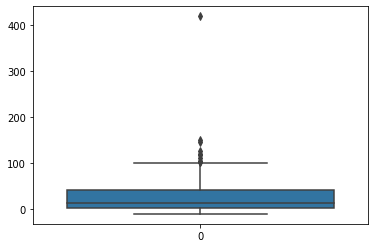

In [462]:
sns.boxplot(data=twoClassdata_df['degree_spondylolisthesis'])
# Right skew with positive outliers. One value seems to be exceptionally higher than rest which could impact mean

In [463]:
#Boxplots are matching in terms of our inferences vis a vis outliers and skews 

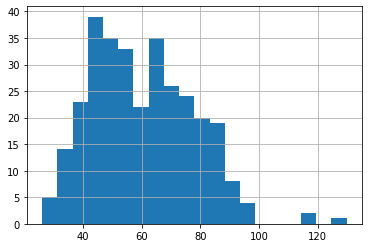

In [464]:
#Let us check if histograms give additional insight (Bimodal etc are not visible in boxplots)
twoClassdata_df['pelvic_incidence'].hist(bins=20)
#maximum data has pelvic_incidence between 41 to 58. There is sharp dip between 58 to 62(absence of data). and two outliers 
# near value of 118 and 129. What does this value represent [wrong data or some abnormality, should consult domain expert]
# Distribution outline seems normal (with two peaks one higher and one smaller)

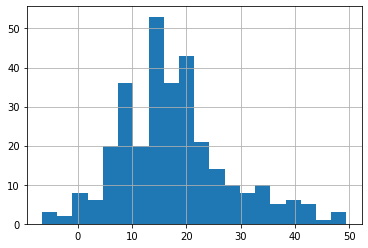

In [465]:
twoClassdata_df['pelvic_tilt numeric'].hist(bins=20)
#normal distribution with more data tapering smoothlytowards right. Maximum number of values around 15-16 value of pelvic tilt
# Top frequencies are at pelvic tilts 15-16, 19-21 followed by 8to10. Do they indicate abnormal or normal values?

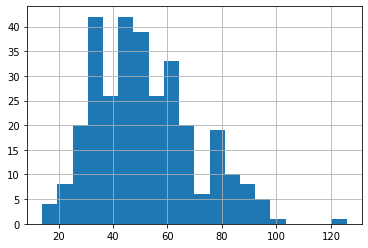

In [466]:
twoClassdata_df['lumbar_lordosis_angle'].hist(bins=20)
#distinct outliers between 120to125 of values for lumbar lordosis. The data has maximum frequencies at 30to35,42to57,59to65 etc
# Do these peaks represent normal or abnormal values. can be verified

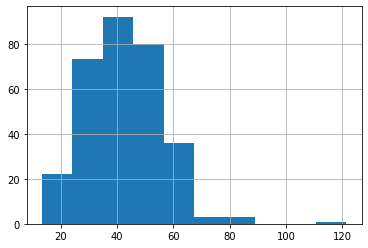

In [467]:
twoClassdata_df['sacral_slope'].hist()
#perfectly normal with outlier at value between 110 to 121. Max number of entries have values between 36 to 45.

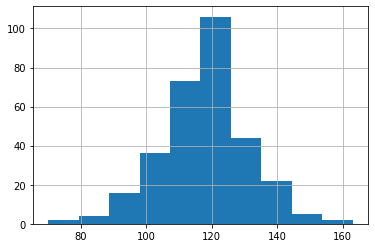

In [468]:
twoClassdata_df['pelvic_radius'].hist()
#normal distribution with maximum frequency between 115 to 128. Skew towards both the ends. When does pelvic radius become exceptionally'
# small or large [represented by skew]. Does it indicate abnormality?

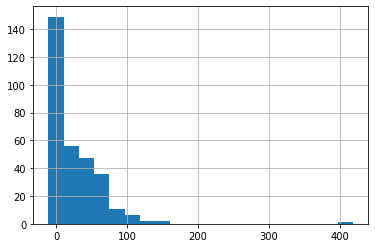

In [469]:
twoClassdata_df['degree_spondylolisthesis'].hist(bins=20)
# Maximum frequency between values of -15 to 15. One outlier exceptionally high with very big difference from next lower
# value indicates wrong data?
# High values get ignored for nearest neighbour calculation for incoming values so knn wont beimpacted?

In [470]:
twoClassdata_df.head()

,pelvic_incidence,pelvic_tilt numeric,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,63.027818,22.552586,39.609117,40.475232,98.672917,-0.254400,Abnormal
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,Abnormal
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,Abnormal
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,Abnormal
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,Abnormal


In [471]:
twoClassdata_df.tail()

,pelvic_incidence,pelvic_tilt numeric,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
305,47.903565,13.616688,36.000000,34.286877,117.449062,-4.245395,Normal
306,53.936748,20.721496,29.220534,33.215251,114.365845,-0.421010,Normal
307,61.446597,22.694968,46.170347,38.751628,125.670725,-2.707880,Normal
308,45.252792,8.693157,41.583126,36.559635,118.545842,0.214750,Normal
309,33.841641,5.073991,36.641233,28.767649,123.945244,-0.199249,Normal


In [472]:
#Finding missing values
twoClassdata_df.isna().sum()
#No missing values

pelvic_incidence            0
pelvic_tilt numeric         0
lumbar_lordosis_angle       0
sacral_slope                0
pelvic_radius               0
degree_spondylolisthesis    0
class                       0
dtype: int64

In [473]:
#finding unique values of 'class'
twoClassdata_df['class'].unique()

array(['Abnormal', 'Normal'], dtype=object)

In [474]:
twoClassdata_df.groupby(['class']).count()
# Both normal and abnormal classes have unequal representation with more representation of 'abnormal' classes, 
# Ratio of abnormal to normal is 2:1
# possible impacts on KNN?
#Abnormal class value has maximum frequency of 210 [almost 68% of total values] so results could be biased towards abnormal
#class. Need to be verified with results

,pelvic_incidence,pelvic_tilt numeric,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis
class,,,,,,
Abnormal,210,210,210,210,210,210
Normal,100,100,100,100,100,100


In [475]:
 # Plot the distribution of different classes for pelvic_radius and sacral_slope for visualization.

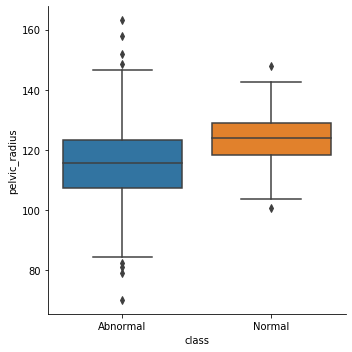

In [476]:
sns.catplot(x='class',y='pelvic_radius', kind = 'box', data=twoClassdata_df)
#pelvic radius spread for abnormal classes is more than normal class. Most Pelvic radius values are less than median of 
#Normal pelvic radius values
# When pelvic radius was exceptionally small and large as indicated by histogram of pelvic radius, we were right that
# it showed abnormal condition
# Most normal classes are spread between 119 to 128 [ As seen in histogram of pelvic radius above, this corresponds to
# maximum frequency]
#other than overlap areas , normal and abnormal values are distinguishable

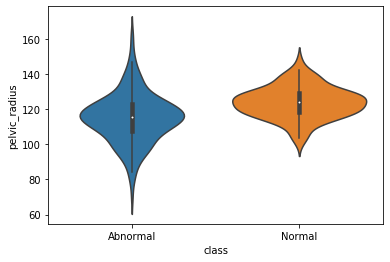

In [477]:
#other than overlap areas , normal and abnormal values are distinguishable
#density plot could lead to more clarity on density distribution of both the classes for pelvic_radius around overlap area
fig, ax = pyplot.subplots(figsize=(6, 4))
sns.violinplot(ax=ax, x=twoClassdata_df["class"], y= twoClassdata_df["pelvic_radius"])
#Normal values have much higher density aroun 120 pelvic radius than abnormal classes


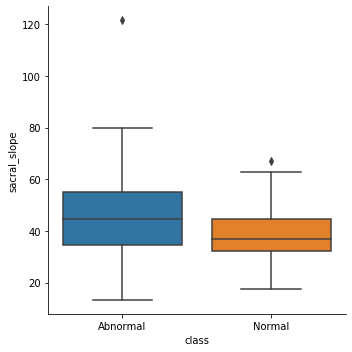

In [478]:
sns.catplot(x='class',y='sacral_slope', kind = 'box', data=twoClassdata_df)
#All the data of normal class lies below the median of abnormal class around 45 . So sacral slope towards
#lower side indicate normal values. There is overlap between two classes below median of abnormal class so very clear
#distinguishability not apparent between values of 35 to 45

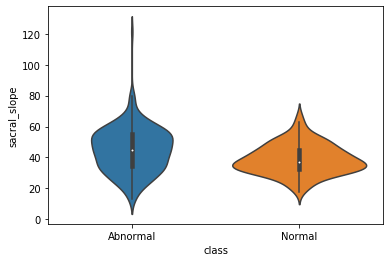

In [479]:
#density plot could lead to more clarity on density distribution of both the classes for sacral_slope
fig, ax = pyplot.subplots(figsize=(6, 4))
sns.violinplot(ax=ax, x=twoClassdata_df["class"], y= twoClassdata_df["sacral_slope"])
# Normal classes have maximum density of data around 30 value
# Abnormal classes have maximum density between 30 to 50 (at 30 its density is not as high as normal values)
# As seen in histogram of sacral slope previously, maximum frequency is between 36 to 45 so major contributor is
# from both normal and abnormal classes though at 35 specifically Normal classes are more contributing.
# Outliers are solely due to abnormal classes


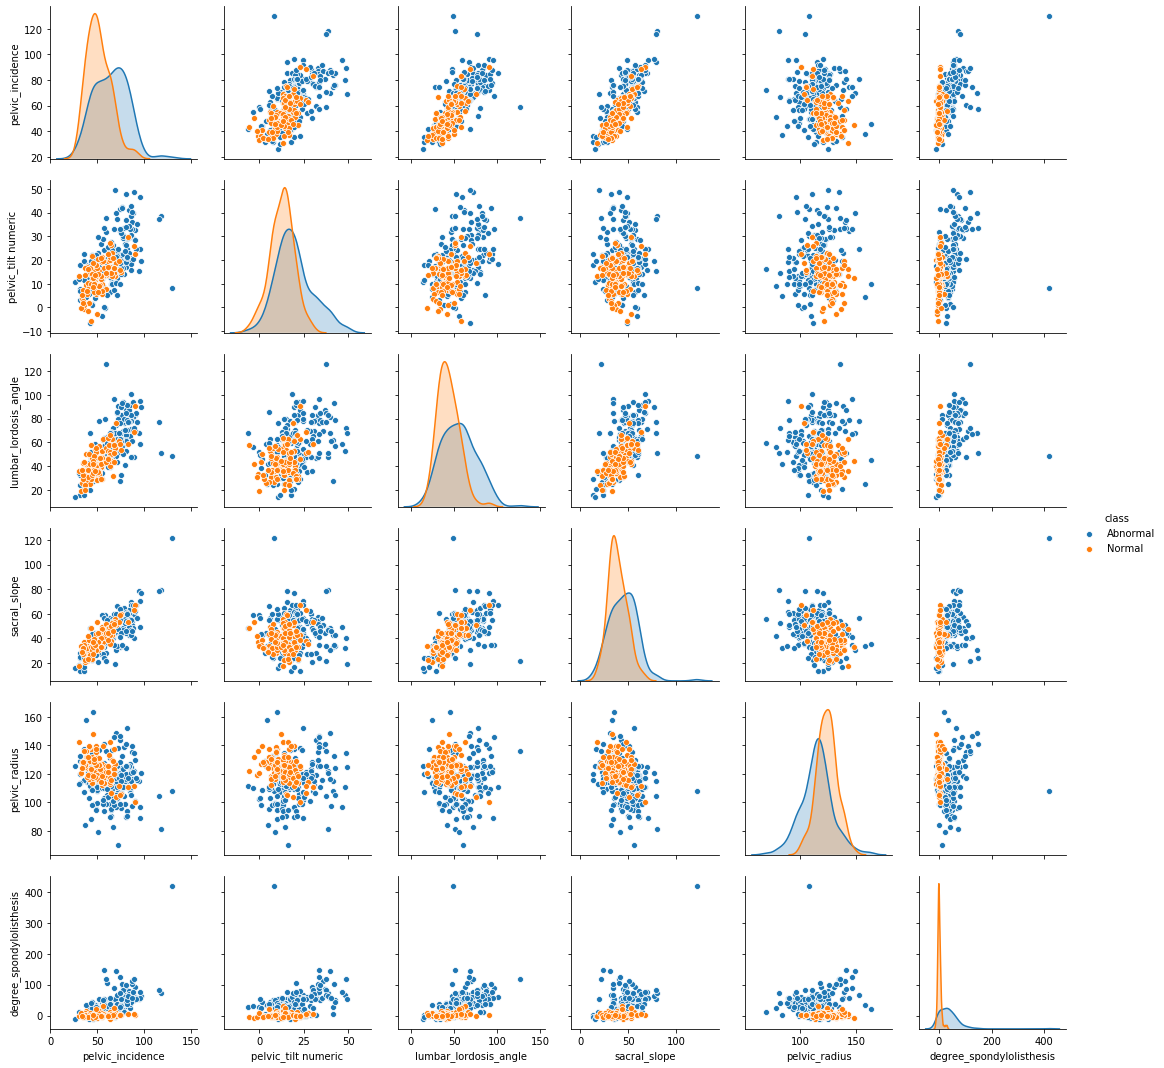

In [480]:
sns.pairplot(twoClassdata_df, hue='class',diag_kind ='kde')

In [481]:
# Data distribution between numeric attributes is shaped like cloud so euclidean distance calculation method for
# nearest neighbour seems apt
# No feature appears to be major differentiator between two classes. Not expecting good results? 

# Encode the Class variable to integer. (2 marks)

In [482]:
#Though class has no natural ordering but we will use LabelEncoder because we cannot use One Hot Encoding
# which leads to two columns (we can have only one target column)
class_encoder = LabelEncoder()
twoClassdata_df['class'] = class_encoder.fit_transform(twoClassdata_df['class'])
twoClassdata_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 7 columns):
pelvic_incidence            310 non-null float64
pelvic_tilt numeric         310 non-null float64
lumbar_lordosis_angle       310 non-null float64
sacral_slope                310 non-null float64
pelvic_radius               310 non-null float64
degree_spondylolisthesis    310 non-null float64
class                       310 non-null int32
dtypes: float64(6), int32(1)
memory usage: 15.8 KB


In [483]:
#check encoding for first few observations having abnormal values
twoClassdata_df.head()
# abnormal encoded as 0

,pelvic_incidence,pelvic_tilt numeric,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,63.027818,22.552586,39.609117,40.475232,98.672917,-0.254400,0
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,0
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,0
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,0
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,0


In [484]:
#check encoding for last few observations having normal values
twoClassdata_df.tail()
# normal encoded as 1

,pelvic_incidence,pelvic_tilt numeric,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
305,47.903565,13.616688,36.000000,34.286877,117.449062,-4.245395,1
306,53.936748,20.721496,29.220534,33.215251,114.365845,-0.421010,1
307,61.446597,22.694968,46.170347,38.751628,125.670725,-2.707880,1
308,45.252792,8.693157,41.583126,36.559635,118.545842,0.214750,1
309,33.841641,5.073991,36.641233,28.767649,123.945244,-0.199249,1


# Create the X(Feature-set) and Y(Target-set) sets for your Data. (2 marks)

In [485]:
#Creating feature set and verifying the feature columns through info()
X = twoClassdata_df.drop("class", axis=1)
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 6 columns):
pelvic_incidence            310 non-null float64
pelvic_tilt numeric         310 non-null float64
lumbar_lordosis_angle       310 non-null float64
sacral_slope                310 non-null float64
pelvic_radius               310 non-null float64
degree_spondylolisthesis    310 non-null float64
dtypes: float64(6)
memory usage: 14.6 KB


In [486]:
#Creating target set and verifying the target column through info()
y = twoClassdata_df[["class"]]
y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 1 columns):
class    310 non-null int32
dtypes: int32(1)
memory usage: 1.3 KB


# Normalize your Data (X) to get values between 0 to 1. (2 marks)

In [487]:
# Since values have to be brought between 0 and 1 zscore cannot be used which can have values till 3 as well
# Max scalar cannot be used as aalmost all features have big outliers which can impact the normalization
#Using MinMaxScaler which uses x-min(X)/max(X)-min(X)

In [488]:
xColumns = X.columns
scaler = MinMaxScaler()
X = scaler.fit_transform(X)
X = pd.DataFrame(X, columns=xColumns)
X.describe().T
#All feature values are between 0 and 1. Min for all features is 0 and max for all features is 1 

,count,mean,std,min,25%,50%,75%,max
pelvic_incidence,310.0,0.331276,0.166237,0.0,0.195613,0.313862,0.450685,1.0
pelvic_tilt numeric,310.0,0.430419,0.178762,0.0,0.307608,0.409251,0.512180,1.0
lumbar_lordosis_angle,310.0,0.339450,0.166043,0.0,0.205831,0.318253,0.438509,1.0
sacral_slope,310.0,0.273794,0.124216,0.0,0.184895,0.268714,0.363946,1.0
pelvic_radius,310.0,0.514452,0.143215,0.0,0.436900,0.518189,0.595613,1.0
degree_spondylolisthesis,310.0,0.086952,0.087428,0.0,0.029474,0.053133,0.121847,1.0


# Split the dat as train and test with a ratio of 70:30. (2 marks)

In [489]:
test_size=0.30 #70:30 train and test ratio
seed=7 #seed for repeatability of results
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

In [490]:
X_train.shape

(217, 6)

In [491]:
X_test.shape

(93, 6)

In [492]:
y_train.shape

(217, 1)

In [493]:
y_test.shape

(93, 1)

In [494]:
# train and test split for fetaure and target variables is successful as confirmed by shape

# Build the KNN model using Train Dataset and predict the class on test dataset. (2 marks)

In [495]:
KNN = KNeighborsClassifier()# default KNN 5
KNN.fit(X_train, y_train)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
                     metric_params=None, n_jobs=None, n_neighbors=5, p=2,
                     weights='uniform')

In [496]:
predicted_labels = KNN.predict(X_test)
predicted_labels
# 1 0 prediction

array([1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 0])

# Calculate the performance score of of your classification on test dataset. (2 marks)
Hint- You can use knn.score( ) function.

In [497]:
#Train accuracy
KNN.score(X_train, y_train)

0.8617511520737328

In [498]:
#Test accuracy
KNN.score(X_test, y_test)

0.7634408602150538

In [499]:
#Train accuracy is more than test accuracy for 5 neighbours. 

In [500]:
#Train confusion matrix
confusion_matrix(y_train, KNN.predict(X_train))

array([[137,  14],
       [ 16,  50]], dtype=int64)

In [501]:
# 0 -abnormal 1-normal , rows actual, columns predicted
#TP = 137 TN = 50 FP = 16 FN = 14
#Correct prediction = 137+50 = 187
#Wrong prediction = 14+16 = 30
#Error Rate = 30/217 = 0.138
#Accuracy = 187/217 = 0.86
# Recall(abnormal) = TP/TP+FN = 137/137+14 = 137/151=0.90 [positives(abnormal) correctly identified] 
# Precision(abnormal) = TP/TP+FP = 137/137+16 = 137/153 = 0.89
# Recall(normal) = 50/66 = 0.75
# Precision (normal) = 50/64= 0.59

In [502]:
#Test confusion matrix
confusion_matrix(y_test, KNN.predict(X_test))

array([[54,  5],
       [17, 17]], dtype=int64)

In [503]:
# 0 -abnormal 1-normal , rows actual, columns predicted
#TP = 54 TN = 17 FP = 17 FN = 5
#Correct prediction = 54+17 = 71
#Wrong prediction = 17+5 = 22
#Error Rate = 22/93
#Accuracy = 71/93
# Recall = TP/TP+FN = 137/137+14 = 137/151=0.90 [positives(abnormal) correctly identified]
# Precision = TP/TP+FP = 137/137+16 = 137/153 = 0.89

# What is the best K value for your classifcation?
#Find at which k value you get the best score. (2 marks)

In [504]:
import warnings 
warnings.filterwarnings('ignore')

In [505]:
#Maximum K value calculation 
maximumK = (int)(np.sqrt(X_train.shape[0])) #square root of number of observations
print(maximumK)

14


In [506]:
#Taking maximumK+1 values as maximumK is 14 which is even. We should take odd k values
klist = list(range(1,15))

In [507]:
#Taking odd k values
kvalues = list(filter(lambda x: x%2 != 0, klist))
print(kvalues)

[1, 3, 5, 7, 9, 11, 13]


In [508]:
# empty list that will hold cv scores
cv_scores = []

In [509]:
# perform 10-fold cross validation
for k in kvalues:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=10, scoring='accuracy')
    cv_scores.append(scores.mean())

In [510]:
# determining best k
#optimal_k = neighbors[misError.index(min(misError))] #commented and following line introduced during lecture
optimal_k = kvalues[cv_scores.index(max(cv_scores))]
print("The optimal number of neighbors is %d" % optimal_k)

The optimal number of neighbors is 13


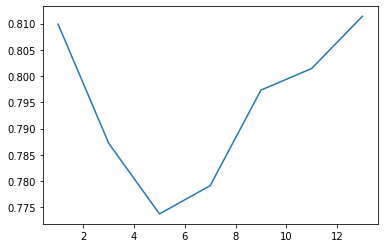

In [563]:
pyplot.plot(kvalues, cv_scores)
#showing max at 13

In [511]:
#fitting data for optimal k
KNN = KNeighborsClassifier(n_neighbors=optimal_k)
KNN.fit(X_train, y_train)
#Train accuracy
KNN.score(X_train, y_train)

0.8202764976958525

In [512]:
#Train accuracy
KNN.score(X_test, y_test)

0.8172043010752689

In [513]:
#Though the accuracy on train is marginally reduced but accuracy of test is increased and accuracy of train and test are almost
#at par indicating that model is not overfit but performs equally on test
#Checking confusion matrix could help us in understanding correctness and error values

In [514]:
#Train confusion matrix
confusion_matrix(y_train, KNN.predict(X_train))

array([[136,  15],
       [ 24,  42]], dtype=int64)

In [515]:
# correct prediction 136+42 = 178 (less than k=5)
# Wrong prediction 24+15 = 39 (more than k=5)

In [516]:
#Train confusion matrix
confusion_matrix(y_test, KNN.predict(X_test))

array([[56,  3],
       [14, 20]], dtype=int64)

In [517]:
#Test accuracy for true positives for abnormal cases is increased also true positive for normal cases is increased
# correct prediction = 56+20 = 76
#wrong prdiction = 3+14 = 17
# correct predition has increased and wrong prediction is reduced from default value

# import data 3C_weka.csv for 3 Class Classifcation and repeat all the steps which are given above. (10 marks)

In [518]:
#Load the other data file
threeClassdata_df = pd.read_csv("3Classdata.csv")

In [519]:
threeClassdata_df.info()
#There are 7 columns (6 float and one object) - Similar datatypes as 2Classdata 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 7 columns):
pelvic_incidence            310 non-null float64
pelvic_tilt                 310 non-null float64
lumbar_lordosis_angle       310 non-null float64
sacral_slope                310 non-null float64
pelvic_radius               310 non-null float64
degree_spondylolisthesis    310 non-null float64
class                       310 non-null object
dtypes: float64(6), object(1)
memory usage: 17.0+ KB


In [520]:
threeClassdata_df.describe().T
#Similar min max outliers as 2classData so same inferences holds true
#all the data is similar except the target class

,count,mean,std,min,25%,50%,75%,max
pelvic_incidence,310.0,60.496653,17.236520,26.147921,46.430294,58.691038,72.877696,129.834041
pelvic_tilt,310.0,17.542822,10.008330,-6.554948,10.667069,16.357689,22.120395,49.431864
lumbar_lordosis_angle,310.0,51.930930,18.554064,14.000000,37.000000,49.562398,63.000000,125.742385
sacral_slope,310.0,42.953831,13.423102,13.366931,33.347122,42.404912,52.695888,121.429566
pelvic_radius,310.0,117.920655,13.317377,70.082575,110.709196,118.268178,125.467674,163.071041
degree_spondylolisthesis,310.0,26.296694,37.559027,-11.058179,1.603727,11.767934,41.287352,418.543082


In [521]:
threeClassdata_df.head()

,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,63.027818,22.552586,39.609117,40.475232,98.672917,-0.254400,Hernia
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,Hernia
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,Hernia
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,Hernia
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,Hernia


In [522]:
threeClassdata_df.tail()

,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
305,47.903565,13.616688,36.000000,34.286877,117.449062,-4.245395,Normal
306,53.936748,20.721496,29.220534,33.215251,114.365845,-0.421010,Normal
307,61.446597,22.694968,46.170347,38.751628,125.670725,-2.707880,Normal
308,45.252792,8.693157,41.583126,36.559635,118.545842,0.214750,Normal
309,33.841641,5.073991,36.641233,28.767649,123.945244,-0.199249,Normal


In [523]:
#Finding missing values
threeClassdata_df.isna().sum()
#No missing values

pelvic_incidence            0
pelvic_tilt                 0
lumbar_lordosis_angle       0
sacral_slope                0
pelvic_radius               0
degree_spondylolisthesis    0
class                       0
dtype: int64

In [524]:
#finding unique values of 'class'
threeClassdata_df['class'].unique()

array(['Hernia', 'Spondylolisthesis', 'Normal'], dtype=object)

In [525]:
threeClassdata_df.groupby(['class']).count()

,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis
class,,,,,,
Hernia,60,60,60,60,60,60
Normal,100,100,100,100,100,100
Spondylolisthesis,150,150,150,150,150,150


In [526]:
#three unique classes with mode as spondylolisthesis which has frequecy of 150 out of 310 i.e. almost 50%
# and rest two Hernia and normal together represent rest(normal data more than hernia ). So results could largely
# be biased towards spndylolisthesis fllowed by normal. However, actual results could be analysed to understand the impact 

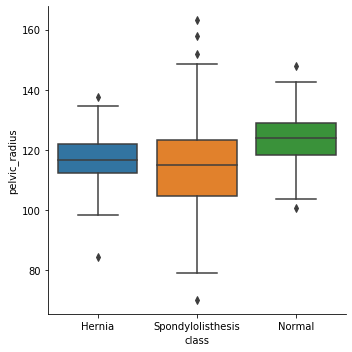

In [527]:
 # Plot the distribution of different classes for pelvic_radius for visualization.
sns.catplot(x='class',y='pelvic_radius',kind='box',data=threeClassdata_df)
# pelvic_radius of normal values are little higher than other two classes. However, below the median of Normal class for
# pelvic radius , all the three classes have overlap of pelvic_radius values. Only nonoverlapping areas of Normal value
# between 122 to 127 and between 105 to 112 for Spondyliolisthesis are distinct which can lead to clear identification

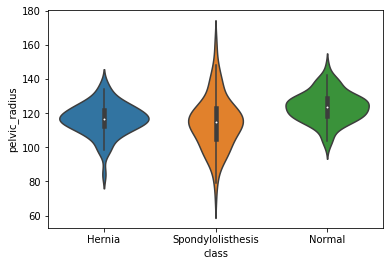

In [528]:
#density plot could lead to more clarity on density distribution of three classes for pelvic_radius
fig, ax = pyplot.subplots(figsize=(6, 4))
sns.violinplot(ax=ax, x=threeClassdata_df["class"], y= threeClassdata_df["pelvic_radius"])
#MAximum density areas of all the three classes are overlapping [around 119 to 121]. Hernia and Normal have much 
#higher density

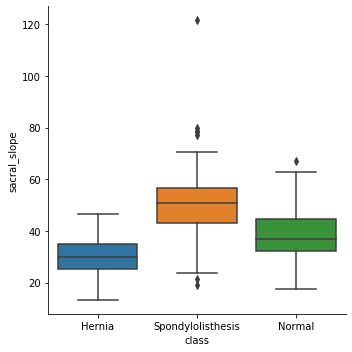

In [529]:
#class vs sacral slope
sns.catplot(x='class',y='sacral_slope',kind='box',data=threeClassdata_df)                  
# sacral_slope of spondylolisthesis class is higher than normal which in turn is higher than Hernia cases.
# There is small overlap of lower edges of higher one with lower classes on this feature.
# Sacral Slope seems to be better distinguishing feature

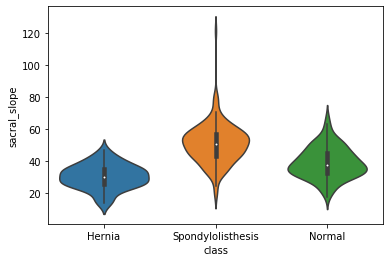

In [530]:
#density plot could lead to more clarity on density distribution of three classes for pelvic_radius
fig, ax = pyplot.subplots(figsize=(6, 4))
sns.violinplot(ax=ax, x=threeClassdata_df["class"], y= threeClassdata_df["sacral_slope"])
# Maximum density area of Spondylolisthesis class is much higher than the other two. Hernia and Normal cases are not
# easily distinguishable due to similar maximum density areas of datapoints 

In [531]:
#Though class has no natural ordering but we will use LabelEncoder because we cannot use One Hot Encoding
# which leads to two columns (we can have only one target column)
class_encoder = LabelEncoder()
threeClassdata_df['class'] = class_encoder.fit_transform(threeClassdata_df['class'])
threeClassdata_df.info()
#Hernia 0
#Normal 1
#Spondylolysthesis 2

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 7 columns):
pelvic_incidence            310 non-null float64
pelvic_tilt                 310 non-null float64
lumbar_lordosis_angle       310 non-null float64
sacral_slope                310 non-null float64
pelvic_radius               310 non-null float64
degree_spondylolisthesis    310 non-null float64
class                       310 non-null int32
dtypes: float64(6), int32(1)
memory usage: 15.8 KB


In [532]:
#0 value for Hernia [were representing abnormal in 2class data]
threeClassdata_df.head()

,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,63.027818,22.552586,39.609117,40.475232,98.672917,-0.254400,0
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,0
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,0
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,0
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,0


In [533]:
#1 value for Normal [were representing normal in 2class data]
threeClassdata_df.tail()

,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
305,47.903565,13.616688,36.000000,34.286877,117.449062,-4.245395,1
306,53.936748,20.721496,29.220534,33.215251,114.365845,-0.421010,1
307,61.446597,22.694968,46.170347,38.751628,125.670725,-2.707880,1
308,45.252792,8.693157,41.583126,36.559635,118.545842,0.214750,1
309,33.841641,5.073991,36.641233,28.767649,123.945244,-0.199249,1


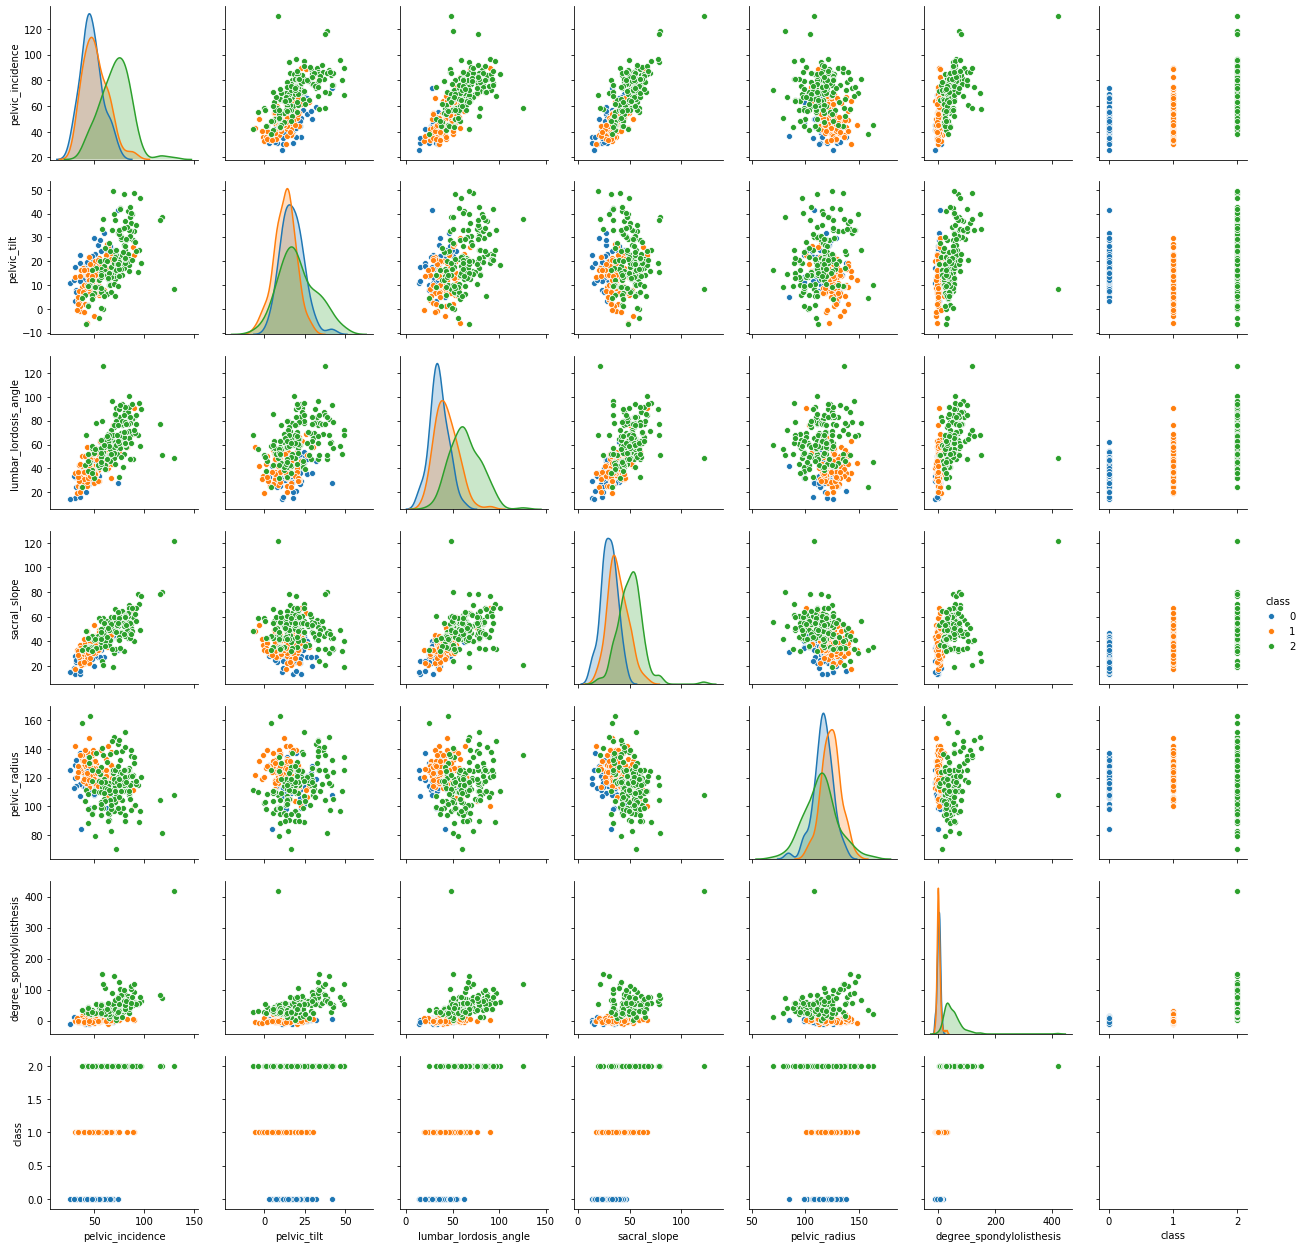

In [534]:
#Pairplot
sns.pairplot(threeClassdata_df, hue='class', diag_kind='kde' )

In [535]:
# Most features have cloud based distribution so euclidean distance method is ok
# (Hernia,Normal) vs Spondyliolisthesis are little distinguishable except for overlap data areas
# Hernia and Normal have similar distribution across features so not easily distinguishable
#High accuracy not expected

In [536]:
#Creating feature set and verifying the feature columns through info()
X = threeClassdata_df.drop("class", axis=1)
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 6 columns):
pelvic_incidence            310 non-null float64
pelvic_tilt                 310 non-null float64
lumbar_lordosis_angle       310 non-null float64
sacral_slope                310 non-null float64
pelvic_radius               310 non-null float64
degree_spondylolisthesis    310 non-null float64
dtypes: float64(6)
memory usage: 14.6 KB


In [537]:
#Creating feature set and verifying the feature columns through info()
y = threeClassdata_df[["class"]]
y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 1 columns):
class    310 non-null int32
dtypes: int32(1)
memory usage: 1.3 KB


In [538]:
#Before KNN Normalization needs to be done so that distance measurements are not biased toward one feature
#Though in this dataset the features are float and none appears to have more weightage
# Normalize to bring values between 0 and 1
xcolumns = X.columns
print(xcolumns)
scalar = MinMaxScaler()
scaled = scalar.fit_transform(X)
X = pd.DataFrame(data=scaled, columns = xcolumns)
X.describe().T

Index(['pelvic_incidence', 'pelvic_tilt', 'lumbar_lordosis_angle',
       'sacral_slope', 'pelvic_radius', 'degree_spondylolisthesis'],
      dtype='object')


,count,mean,std,min,25%,50%,75%,max
pelvic_incidence,310.0,0.331276,0.166237,0.0,0.195613,0.313862,0.450685,1.0
pelvic_tilt,310.0,0.430419,0.178762,0.0,0.307608,0.409251,0.512180,1.0
lumbar_lordosis_angle,310.0,0.339450,0.166043,0.0,0.205831,0.318253,0.438509,1.0
sacral_slope,310.0,0.273794,0.124216,0.0,0.184895,0.268714,0.363946,1.0
pelvic_radius,310.0,0.514452,0.143215,0.0,0.436900,0.518189,0.595613,1.0
degree_spondylolisthesis,310.0,0.086952,0.087428,0.0,0.029474,0.053133,0.121847,1.0


In [539]:
#ALL features have been normalied as seen in min(0) and max(1) values of each feature

In [540]:
#Perform train and test split[should be same as earlier as we are using same seed and ratio]
test_size=0.30 #70:30 train and test ratio
seed=7 #seed for repeatability of results
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

In [541]:
X_train.shape

(217, 6)

In [542]:
y_train.shape

(217, 1)

In [543]:
X_test.shape

(93, 6)

In [544]:
y_test.shape

(93, 1)

In [545]:
#Trying default neighbors of 5
KNN2 = KNeighborsClassifier()
KNN2.fit(X_train, y_train)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
                     metric_params=None, n_jobs=None, n_neighbors=5, p=2,
                     weights='uniform')

In [546]:
predicted = KNN2.predict(X_test)
predicted
#0 1 2 predict

array([1, 2, 2, 2, 0, 1, 2, 2, 1, 2, 0, 2, 0, 1, 2, 2, 2, 1, 1, 0, 2, 2,
       2, 0, 0, 1, 1, 2, 2, 2, 1, 2, 0, 2, 2, 2, 2, 2, 2, 2, 0, 1, 1, 0,
       2, 0, 0, 1, 2, 1, 2, 1, 0, 2, 2, 2, 2, 2, 0, 2, 2, 1, 2, 2, 2, 1,
       2, 2, 0, 0, 2, 1, 0, 2, 0, 2, 0, 1, 1, 2, 2, 2, 1, 0, 0, 1, 2, 1,
       1, 2, 2, 0, 0])

In [547]:
KNN2.score(X_train, y_train)

0.8387096774193549

In [548]:
KNN2.score(X_test, y_test)

0.7204301075268817

In [549]:
#Train confusion matrix
confusion_matrix(y_train, KNN2.predict(X_train))

array([[42,  6,  1],
       [ 9, 50,  7],
       [ 3,  9, 90]], dtype=int64)

In [550]:
#Test Confusion Matrix
confusion_matrix(y_test, KNN2.predict(X_test))

array([[ 7,  3,  1],
       [11, 18,  5],
       [ 4,  2, 42]], dtype=int64)

In [551]:
maximumK = (int)(np.sqrt(X_train.shape[0])) #square root of number of observations
print(maximumK)

14


In [552]:
#Taking maximumK+1 values as maximumK is 14 which is even. We should take odd k values
klist = list(range(1,15))

In [553]:
#Taking odd k values
kvalues = list(filter(lambda x: x%2 != 0, klist))
print(kvalues)

[1, 3, 5, 7, 9, 11, 13]


In [554]:
# empty list that will hold cv scores
cv_scores2 = []

In [555]:
# perform 10-fold cross validation
for k in kvalues:
    knn2 = KNeighborsClassifier(n_neighbors=k)
    scores2 = cross_val_score(knn2, X_train, y_train, cv=10, scoring='accuracy')
    cv_scores2.append(scores2.mean())

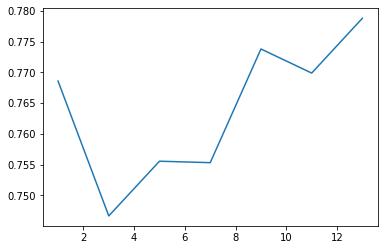

In [564]:
pyplot.plot(kvalues, cv_scores2)
#showing max at 13

In [556]:
# determining best k
optimal_k = kvalues[cv_scores2.index(max(cv_scores2))]
print("The optimal number of neighbors is %d" % optimal_k)

The optimal number of neighbors is 13


In [557]:
#fitting data for optimal k
KNN2 = KNeighborsClassifier(n_neighbors=optimal_k)
KNN2.fit(X_train, y_train)
#Train accuracy
KNN2.score(X_train, y_train)

0.7926267281105991

In [558]:
#Test accuracy
KNN2.score(X_test, y_test)

0.7956989247311828

In [ ]:
#Test accuracy is better than default k and train and test accuracies are at par with optimal k

In [559]:
#Train confusion matrix
confusion_matrix(y_train, KNN2.predict(X_train))

array([[35, 11,  3],
       [14, 47,  5],
       [ 2, 10, 90]], dtype=int64)

In [560]:
#Test confusion matrix
confusion_matrix(y_test, KNN2.predict(X_test))

array([[ 9,  1,  1],
       [ 5, 23,  6],
       [ 2,  4, 42]], dtype=int64)

In [561]:
# Test confusion matrix is giving better correct predictions than optimal K

In [ ]:
#Conclusion : 
# In this exercise, we observed that features had overlapping values for all the classes whther two class or
# three class classification. 
#
# Optimal K value came out to be same for two class or three class classification and in both
# the cases, optimal k value of 13 performed better than k value of 5
#
# Accuracy score of three class classification was little lower than two class classification. This was becuasenew class
# Hernia was closely overlapping with Normal classes. No new feature was introduced for better separatibility
# 
# On optimized K values true positives are increasing across train and test in both the cases
#
# Being a medical dataset where correct dignosis is critical, accuracy score above 0.90 is desirable so KNN is not
# apt for this scenario [or further tuning needed]  